In [1]:
!pip install -q monai nibabel matplotlib
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 108.3 MB/s eta 0:00:00


In [2]:
import os
import glob
import random
import numpy as np
from scipy.ndimage import label
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader
import monai
from monai.data import Dataset, CacheDataset, decollate_batch, list_data_collate
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    NormalizeIntensityd,
    CropForegroundd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandRotate90d,
    EnsureTyped,
    MapTransform,
    Activations,
    AsDiscrete,
    SpatialPadd,
    RandScaleIntensityd,
    RandShiftIntensityd,
    RandGaussianNoised,
    RandZoomd

)
from monai.networks.nets import AttentionUnet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from monai.utils import set_determinism
from monai.config import print_config

print_config()

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


MONAI version: 1.5.2
Numpy version: 2.0.2
Pytorch version: 2.10.0+cu128
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /usr/local/lib/python3.12/dist-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.2
scikit-image version: 0.25.2
scipy version: 1.16.3
Pillow version: 11.3.0
Tensorboard version: 2.19.0
gdown version: 5.2.1
TorchVision version: 0.25.0+cu128
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 5.9.5
pandas version: 2.2.2
einops version: 0.8.2
transformers version: 5.0.0
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: NOT INSTALLED or UNKNOWN VERSION.
clearml version: NOT INSTALLED or UNKNOWN VERSION.

For details about installing the optional dependencies, please visit:
    https://docs.monai.io/en/la

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

RAW_TAR = "/content/drive/MyDrive/BraTS2021_raw/BraTS2021_Training_Data.tar"
EXTRACT_ROOT = "/content/BraTS2021_extracted"
os.makedirs(EXTRACT_ROOT, exist_ok=True)
!tar -xf {RAW_TAR} -C {EXTRACT_ROOT}

In [5]:

root = "/content/BraTS2021_extracted"
print("Folders:", len([d for d in os.listdir(root) if os.path.isdir(os.path.join(root, d))]))
print("Flair files:", len(glob.glob(os.path.join(root, "*", "*_flair.nii.gz"))))
print("Tar files:", len(glob.glob(os.path.join(root, "*.tar"))))

Folders: 1251
Flair files: 1251
Tar files: 0


**build_brats_datalist()**

In [6]:
def build_brats_datalist_multimodal(data_root):
    cases = sorted([d for d in glob.glob(os.path.join(data_root, "*")) if os.path.isdir(d)])
    datalist = []

    for case_dir in cases:
        case_id = os.path.basename(case_dir)

        t1 = glob.glob(os.path.join(case_dir, "*_t1.nii.gz"))
        t1ce = glob.glob(os.path.join(case_dir, "*_t1ce.nii.gz"))
        t2 = glob.glob(os.path.join(case_dir, "*_t2.nii.gz"))
        flair = glob.glob(os.path.join(case_dir, "*_flair.nii.gz"))
        seg = glob.glob(os.path.join(case_dir, "*_seg.nii.gz"))

        if len(t1) == 1 and len(t1ce) == 1 and len(t2) == 1 and len(flair) == 1 and len(seg) == 1:
            datalist.append({
                "image": [t1[0], t1ce[0], t2[0], flair[0]],
                "label": seg[0],
                "case_id": case_id
            })
        else:
            print(f"Skipping {case_id}")

    print("Total valid cases:", len(datalist))
    return datalist

In [7]:
DATA_ROOT = "/content/drive/MyDrive/BraTS2021_extracted"

all_files = build_brats_datalist_multimodal(DATA_ROOT)
print("Total cases found:", len(all_files))
print(all_files[:2])

Total valid cases: 1251
Total cases found: 1251
[{'image': ['/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00000/BraTS2021_00000_t1.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00000/BraTS2021_00000_t1ce.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00000/BraTS2021_00000_t2.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00000/BraTS2021_00000_flair.nii.gz'], 'label': '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00000/BraTS2021_00000_seg.nii.gz', 'case_id': 'BraTS2021_00000'}, {'image': ['/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00002/BraTS2021_00002_t1.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00002/BraTS2021_00002_t1ce.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00002/BraTS2021_00002_t2.nii.gz', '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00002/BraTS2021_00002_flair.nii.gz'], 'label': '/content/drive/MyDrive/BraTS2021_extracted/BraTS2021_00002/BraTS2021_00002

In [8]:

random.seed(42)
random.shuffle(all_files)

val_ratio = 0.2
val_size = int(len(all_files) * val_ratio)

val_files = all_files[:val_size]
train_files = all_files[val_size:]

print("Train cases:", len(train_files))
print("Val cases:", len(val_files))

Train cases: 1001
Val cases: 250


In [9]:
"""
class ConvertToBinaryLabeld(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key] = (d[key] > 0).astype(np.float32)
        return d
"""

class ConvertBraTSMultiChannelLabeld(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)

        for key in self.keys:
            label = d[key]
            if label.ndim == 4 and label.shape[0] == 1:
                label = label[0]
            wt = (label > 0).astype(np.float32)
            tc = np.logical_or(label == 1, label == 4).astype(np.float32)
            et = (label == 4).astype(np.float32)
            d[key] = np.stack([wt, tc, et], axis=0)

        return d

In [10]:
CONFIG = {
    "spacing": (1.0, 1.0, 1.0),
    "roi_size": (96, 96, 96),
    "num_samples": 4,
    "pos": 1,
    "neg": 1,
    "cache_rate": 1.0,
    "num_workers": 12,
    "batch_size": 8,
}

In [11]:
train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(keys=["image", "label"], axcodes="RAS"),

    Spacingd(
        keys=["image", "label"],
        pixdim=CONFIG["spacing"],
        mode=("bilinear", "nearest")
    ),

    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),

    CropForegroundd(keys=["image", "label"], source_key="image"),

    SpatialPadd(
        keys=["image", "label"],
        spatial_size=CONFIG["roi_size"]
    ),


    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=CONFIG["roi_size"],
        pos=CONFIG["pos"],
        neg=CONFIG["neg"],
        num_samples=CONFIG["num_samples"],
        image_key="image",
        image_threshold=0
    ),

    ConvertBraTSMultiChannelLabeld(keys=["label"]),

    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),

    RandScaleIntensityd(keys=["image"], factors=0.1, prob=0.5),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5),
    RandGaussianNoised(keys=["image"], prob=0.2, std=0.01),

    RandZoomd(
        keys=["image", "label"],
        prob=0.2,
        min_zoom=0.9,
        max_zoom=1.1,
        mode=("trilinear", "nearest")
    ),

    EnsureTyped(keys=["image", "label"]),
])

/usr/local/lib/python3.12/dist-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


In [12]:
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),

    EnsureChannelFirstd(keys=["image", "label"]),

    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(
        keys=["image", "label"],
        pixdim=CONFIG["spacing"],
        mode=("bilinear", "nearest")
    ),

    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    SpatialPadd(
        keys=["image", "label"],
        spatial_size=CONFIG["roi_size"]
    ),

    ConvertBraTSMultiChannelLabeld(keys=["label"]),

    EnsureTyped(keys=["image", "label"]),
])

In [13]:
sample = train_files[0]
out = train_transforms(sample)

if isinstance(out, list):
    print("Returned list length:", len(out))
    print("Image shape:", out[0]["image"].shape)
    print("Label shape:", out[0]["label"].shape)
else:
    print("Image shape:", out["image"].shape)
    print("Label shape:", out["label"].shape)

Returned list length: 4
Image shape: torch.Size([4, 96, 96, 96])
Label shape: torch.Size([3, 96, 96, 96])


In [14]:
"""
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=CONFIG["num_workers"]
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=CONFIG["cache_rate"],
    num_workers=CONFIG["num_workers"]
)
"""

train_ds = Dataset(data=train_files, transform=train_transforms)
val_ds = Dataset(data=val_files, transform=val_transforms)

In [15]:

train_loader = DataLoader(
    train_ds,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=torch.cuda.is_available(),
    collate_fn=list_data_collate,
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    collate_fn=list_data_collate,
)

In [16]:
batch = next(iter(train_loader))
print("Train image shape:", batch["image"].shape)
print("Train label shape:", batch["label"].shape)
print("Train label unique values:", torch.unique(batch["label"]))

Train image shape: torch.Size([32, 4, 96, 96, 96])
Train label shape: torch.Size([32, 3, 96, 96, 96])
Train label unique values: metatensor([0., 1.])


In [17]:
val_batch = next(iter(val_loader))

print("Val image shape:", val_batch["image"].shape)
print("Val label shape:", val_batch["label"].shape)
print("Val label unique values:", torch.unique(val_batch["label"]))

Val image shape: torch.Size([1, 4, 139, 178, 127])
Val label shape: torch.Size([1, 3, 139, 178, 127])
Val label unique values: metatensor([0., 1.])


Attention U-Net / loss function

In [18]:
import torch
import torch.nn as nn
class FocalTverskyLoss(nn.Module):
    def __init__(self, alpha=0.3, beta=0.7, gamma=0.75, smooth=1e-5):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, logits, targets):
        # logits: [B, C, D, H, W]
        # targets: [B, C, D, H, W]

        probs = torch.sigmoid(logits)

        dims = tuple(range(2, probs.ndim))  # spatial dims only

        tp = torch.sum(probs * targets, dim=dims)
        fp = torch.sum(probs * (1 - targets), dim=dims)
        fn = torch.sum((1 - probs) * targets, dim=dims)

        tversky = (tp + self.smooth) / (
            tp + self.alpha * fp + self.beta * fn + self.smooth
        )

        focal_tversky = torch.pow((1 - tversky), self.gamma)

        return focal_tversky.mean()

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AttentionUnet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2)
).to(device)

loss_function = FocalTverskyLoss(alpha=0.55, beta=0.45, gamma=1.2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

print(f"Using device: {device}")

Using device: cuda


In [20]:
model.eval()

with torch.no_grad():

    if isinstance(batch, list):
        batch = batch[0]

    x = batch["image"].to(device)
    y = batch["label"].to(device)

    logits = model(x)
    loss = loss_function(logits, y)

print("Input shape:", x.shape)
print("Output shape:", logits.shape)
print("Loss:", loss.item())

Input shape: torch.Size([32, 4, 96, 96, 96])
Output shape: torch.Size([32, 3, 96, 96, 96])
Loss: 0.9293273687362671


optimizer、metric、post-processing

In [21]:
def keep_largest_connected_component(pred_mask):
    """
    pred_mask: numpy array, shape [D, H, W], values 0/1
    """
    labeled_array, num_features = label(pred_mask)

    if num_features == 0:
        return pred_mask

    largest_component = 0
    largest_size = 0

    for comp_id in range(1, num_features + 1):
        comp_size = np.sum(labeled_array == comp_id)
        if comp_size > largest_size:
            largest_size = comp_size
            largest_component = comp_id

    return (labeled_array == largest_component).astype(np.float32)

In [22]:

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

dice_metric = DiceMetric(include_background=True, reduction="mean")

post_sigmoid = Activations(sigmoid=True)
post_pred = AsDiscrete(threshold=0.5)

Define the validation function

In [23]:
def validate(model, val_loader, device, loss_function, infer_roi_size=(96, 96, 96), sw_batch_size=1):
    model.eval()
    val_loss = 0.0
    count = 0
    eps = 1e-8

    wt_scores = []
    tc_scores = []
    et_scores = []

    with torch.no_grad():
        for val_batch in val_loader:
            if isinstance(val_batch, list):
                val_batch = val_batch[0]

            val_images = val_batch["image"].to(device)
            val_labels = val_batch["label"].to(device)

            if val_images.shape[1] != 4:
                raise ValueError(f"Expected 4 image channels in validation, got {val_images.shape}")
            if val_labels.shape[1] != 3:
                raise ValueError(f"Expected 3 label channels in validation, got {val_labels.shape}")

            with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
                val_outputs = sliding_window_inference(
                    inputs=val_images,
                    roi_size=infer_roi_size,
                    sw_batch_size=sw_batch_size,
                    predictor=model
                )
                loss = loss_function(val_outputs, val_labels)

            val_loss += loss.item()
            count += 1

            val_outputs = torch.sigmoid(val_outputs)
            val_outputs = (val_outputs > 0.5).float()

            # channel 0 = WT, 1 = TC, 2 = ET
            for c, score_list in zip(range(3), [wt_scores, tc_scores, et_scores]):
                pred_c = val_outputs[:, c:c+1]
                label_c = val_labels[:, c:c+1]

                intersection = (pred_c * label_c).sum().item()
                denominator = pred_c.sum().item() + label_c.sum().item()

                if denominator == 0:
                    dice = 1.0
                else:
                    dice = (2.0 * intersection + eps) / (denominator + eps)

                score_list.append(dice)

    mean_val_loss = val_loss / max(count, 1)
    mean_wt = sum(wt_scores) / max(len(wt_scores), 1)
    mean_tc = sum(tc_scores) / max(len(tc_scores), 1)
    mean_et = sum(et_scores) / max(len(et_scores), 1)

    return mean_val_loss, mean_wt, mean_tc, mean_et

In [ ]:
OUTPUT_ROOT = "/content/drive/MyDrive/brats_attention_unet_baseline"
os.makedirs(OUTPUT_ROOT, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, "checkpoints"), exist_ok=True)

best_metric = 0.8534
best_metric_epoch = 48
train_loss_history = []
val_loss_history = []
val_wt_history = []
val_tc_history = []
val_et_history = []

checkpoint_path = os.path.join(OUTPUT_ROOT, "checkpoints", "best_model_3channel_focalV4.pth")

max_epochs = 100
val_interval = 4

In [ ]:

checkpoint_path = "/content/drive/MyDrive/brats_attention_unet_baseline/checkpoints/best_model_3channel_focalV4.pth"

model.load_state_dict(torch.load(checkpoint_path))

print("✅ done ！")


✅ done ！


Training Loop

In [ ]:
scaler = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())
extra_epochs = 52
start_epoch = 48
for epoch in range(start_epoch, start_epoch + extra_epochs):

    print("-" * 80)

    print(f"Epoch {epoch + 1}/{start_epoch + extra_epochs}")

    model.train()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        if isinstance(batch_data, list):
            batch_data = batch_data[0]

        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        if inputs.shape[1] != 4:
            raise ValueError(f"Expected 4 image channels, got {inputs.shape}")
        if labels.shape[1] != 3:
            raise ValueError(f"Expected 3 label channels, got {labels.shape}")

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast("cuda", enabled=torch.cuda.is_available()):
            outputs = model(inputs)

           )
            loss_wt = loss_function(outputs[:, 0:1, ...], labels[:, 0:1, ...])
            loss_tc = loss_function(outputs[:, 1:2, ...], labels[:, 1:2, ...])
            loss_et = loss_function(outputs[:, 2:3, ...], labels[:, 2:3, ...])


            weight_wt = 0.3
            weight_tc = 0.3
            weight_et = 0.4


            loss = (weight_wt * loss_wt) + (weight_tc * loss_tc) + (weight_et * loss_et)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        step += 1

        if step % 50 == 0:
            print(f"  step {step}/{len(train_loader)}, train_loss={loss.item():.4f}")

    epoch_loss /= max(step, 1)
    train_loss_history.append(epoch_loss)

    print(f"Epoch {epoch + 1} average train loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        val_loss, val_wt, val_tc, val_et = validate(
            model=model,
            val_loader=val_loader,
            device=device,
            loss_function=loss_function,
            infer_roi_size=(96, 96, 96),
            sw_batch_size=4
        )

        val_loss_history.append(val_loss)
        val_wt_history.append(val_wt)
        val_tc_history.append(val_tc)
        val_et_history.append(val_et)

        print(f"Validation loss: {val_loss:.4f}")
        print(f"Validation WT Dice: {val_wt:.4f}")
        print(f"Validation TC Dice: {val_tc:.4f}")
        print(f"Validation ET Dice: {val_et:.4f}")

        current_metric = (val_wt + val_tc + val_et) / 3.0

        if current_metric > best_metric:
            best_metric = current_metric
            best_metric_epoch = epoch + 1
            torch.save(model.state_dict(), checkpoint_path)
            print("Saved new best model")

        print(f"Current best mean dice: {best_metric:.4f} at epoch {best_metric_epoch}")

print("Continue training completed")
print(f"Best Mean Dice: {best_metric:.4f} at epoch {best_metric_epoch}")

--------------------------------------------------------------------------------
Epoch 49/100
  step 50/126, train_loss=0.1317
  step 100/126, train_loss=0.1977
Epoch 49 average train loss: 0.1972
--------------------------------------------------------------------------------
Epoch 50/100
  step 50/126, train_loss=0.1196
  step 100/126, train_loss=0.1392
Epoch 50 average train loss: 0.1995
--------------------------------------------------------------------------------
Epoch 51/100
  step 50/126, train_loss=0.1438
  step 100/126, train_loss=0.1567
Epoch 51 average train loss: 0.1913
--------------------------------------------------------------------------------
Epoch 52/100
  step 50/126, train_loss=0.1920
  step 100/126, train_loss=0.2701
Epoch 52 average train loss: 0.1932
Validation loss: 0.1761
Validation WT Dice: 0.8900
Validation TC Dice: 0.8417
Validation ET Dice: 0.8246
Current best mean dice: 0.8534 at epoch 48
----------------------------------------------------------------

Training Curve

In [ ]:
plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
plt.plot(train_loss_history)
plt.title("Train Loss")

plt.subplot(1, 5, 2)
plt.plot(val_loss_history)
plt.title("Val Loss")

plt.subplot(1, 5, 3)
plt.plot(val_wt_history)
plt.title("WT Dice")

plt.subplot(1, 5, 4)
plt.plot(val_tc_history)
plt.title("TC Dice")

plt.subplot(1, 5, 5)
plt.plot(val_et_history)
plt.title("ET Dice")

plt.tight_layout()
plt.show()

In [ ]:


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


OUTPUT_ROOT = "/content/drive/MyDrive/brats_attention_unet_baseline"
checkpoint_path = os.path.join(OUTPUT_ROOT, "checkpoints", "best_model_3channel_focalV4.pth")

print(f"🔄  {checkpoint_path}")
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

model.eval()

print("done✅")

🔄 正在加载权重: /content/drive/MyDrive/brats_attention_unet_baseline/checkpoints/best_model_3channel_focalV4.pth
✅ 模型灵魂注入成功！现在可以跑画图代码了！


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

def plot_best_median_worst(val_data_list, model, val_transforms, device):
    
    model.eval()

   
    dice_metric = DiceMetric(include_background=True, reduction="none")

    results = []
    print(" Best, Median, Worst cases")

    with torch.no_grad():
        for i, batch_data in enumerate(val_data_list):
            val_inputs = batch_data["image"].unsqueeze(0).to(device)
            val_labels = batch_data["label"].unsqueeze(0).to(device)

            
            val_outputs = sliding_window_inference(val_inputs, (96, 96, 96), 4, model)
            val_outputs = (val_outputs > 0.5).float() 

            
            dice_metric(y_pred=val_outputs, y=val_labels)
            raw_dice = dice_metric.aggregate() 

           
            wt_dice = raw_dice[0, 0].item()
            tc_dice = raw_dice[0, 1].item()
            et_dice = raw_dice[0, 2].item()

          
            dice_array = np.array([wt_dice, tc_dice, et_dice])
            mean_dice = np.nanmean(dice_array)

            dice_metric.reset()

      
            results.append({
                "idx": i,
                "dice": mean_dice, 
                "wt_dice": wt_dice,
                "tc_dice": tc_dice,
                "et_dice": et_dice,
                "image": val_inputs[0].cpu().numpy(),
                "label": val_labels[0].cpu().numpy(),
                "pred": val_outputs[0].cpu().numpy()
            })

    
    results.sort(key=lambda x: x["dice"] if not np.isnan(x["dice"]) else -1)

    worst_case = results[0]
    median_case = results[len(results) // 2]
    best_case = results[-1]

    cases_to_plot = [
        ("Best Case", best_case),
        ("Median Case", median_case),
        ("Worst Case", worst_case)
    ]

    
    colors = ['green', 'yellow', 'red']

    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    plt.subplots_adjust(wspace=0.05, hspace=0.2)

    for row_idx, (title, case_data) in enumerate(cases_to_plot):
        img_np = case_data["image"]
        lbl_np = case_data["label"]
        prd_np = case_data["pred"]

      
        wt_score = case_data["wt_dice"]
        tc_score = case_data["tc_dice"]
        et_score = case_data["et_dice"]

    
        wt_label = lbl_np[0, :, :, :] # WT channel
        z_slice = np.argmax(np.sum(wt_label, axis=(0, 1)))

       
        bg_img = img_np[3, :, :, z_slice]

    
        axes[row_idx, 0].imshow(bg_img, cmap="gray", origin="lower")
        axes[row_idx, 0].set_title(f"{title}\nWT: {wt_score:.4f} | TC: {tc_score:.4f} | ET: {et_score:.4f}", fontsize=11)
        axes[row_idx, 0].axis('off')

      
        axes[row_idx, 1].imshow(bg_img, cmap="gray", origin="lower")
        for c in range(3):
            mask = lbl_np[c, :, :, z_slice]
            mask_masked = np.ma.masked_where(mask == 0, mask)
            axes[row_idx, 1].imshow(mask_masked, cmap=ListedColormap([colors[c]]), alpha=0.5, origin="lower")
        axes[row_idx, 1].set_title(f"Ground Truth", fontsize=12)
        axes[row_idx, 1].axis('off')

       
        axes[row_idx, 2].imshow(bg_img, cmap="gray", origin="lower")
        for c in range(3):
            mask = prd_np[c, :, :, z_slice]
            mask_masked = np.ma.masked_where(mask == 0, mask)
            axes[row_idx, 2].imshow(mask_masked, cmap=ListedColormap([colors[c]]), alpha=0.5, origin="lower")
        axes[row_idx, 2].set_title(f"Model Prediction", fontsize=12)
        axes[row_idx, 2].axis('off')

    plt.tight_layout()
    plt.savefig("brats_qualitative_results_3scores.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.show()

正在扫描验证集，寻找 Best, Median, Worst cases... 这可能需要几分钟...


/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/usr/local/lib/python3.12/dist-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  out

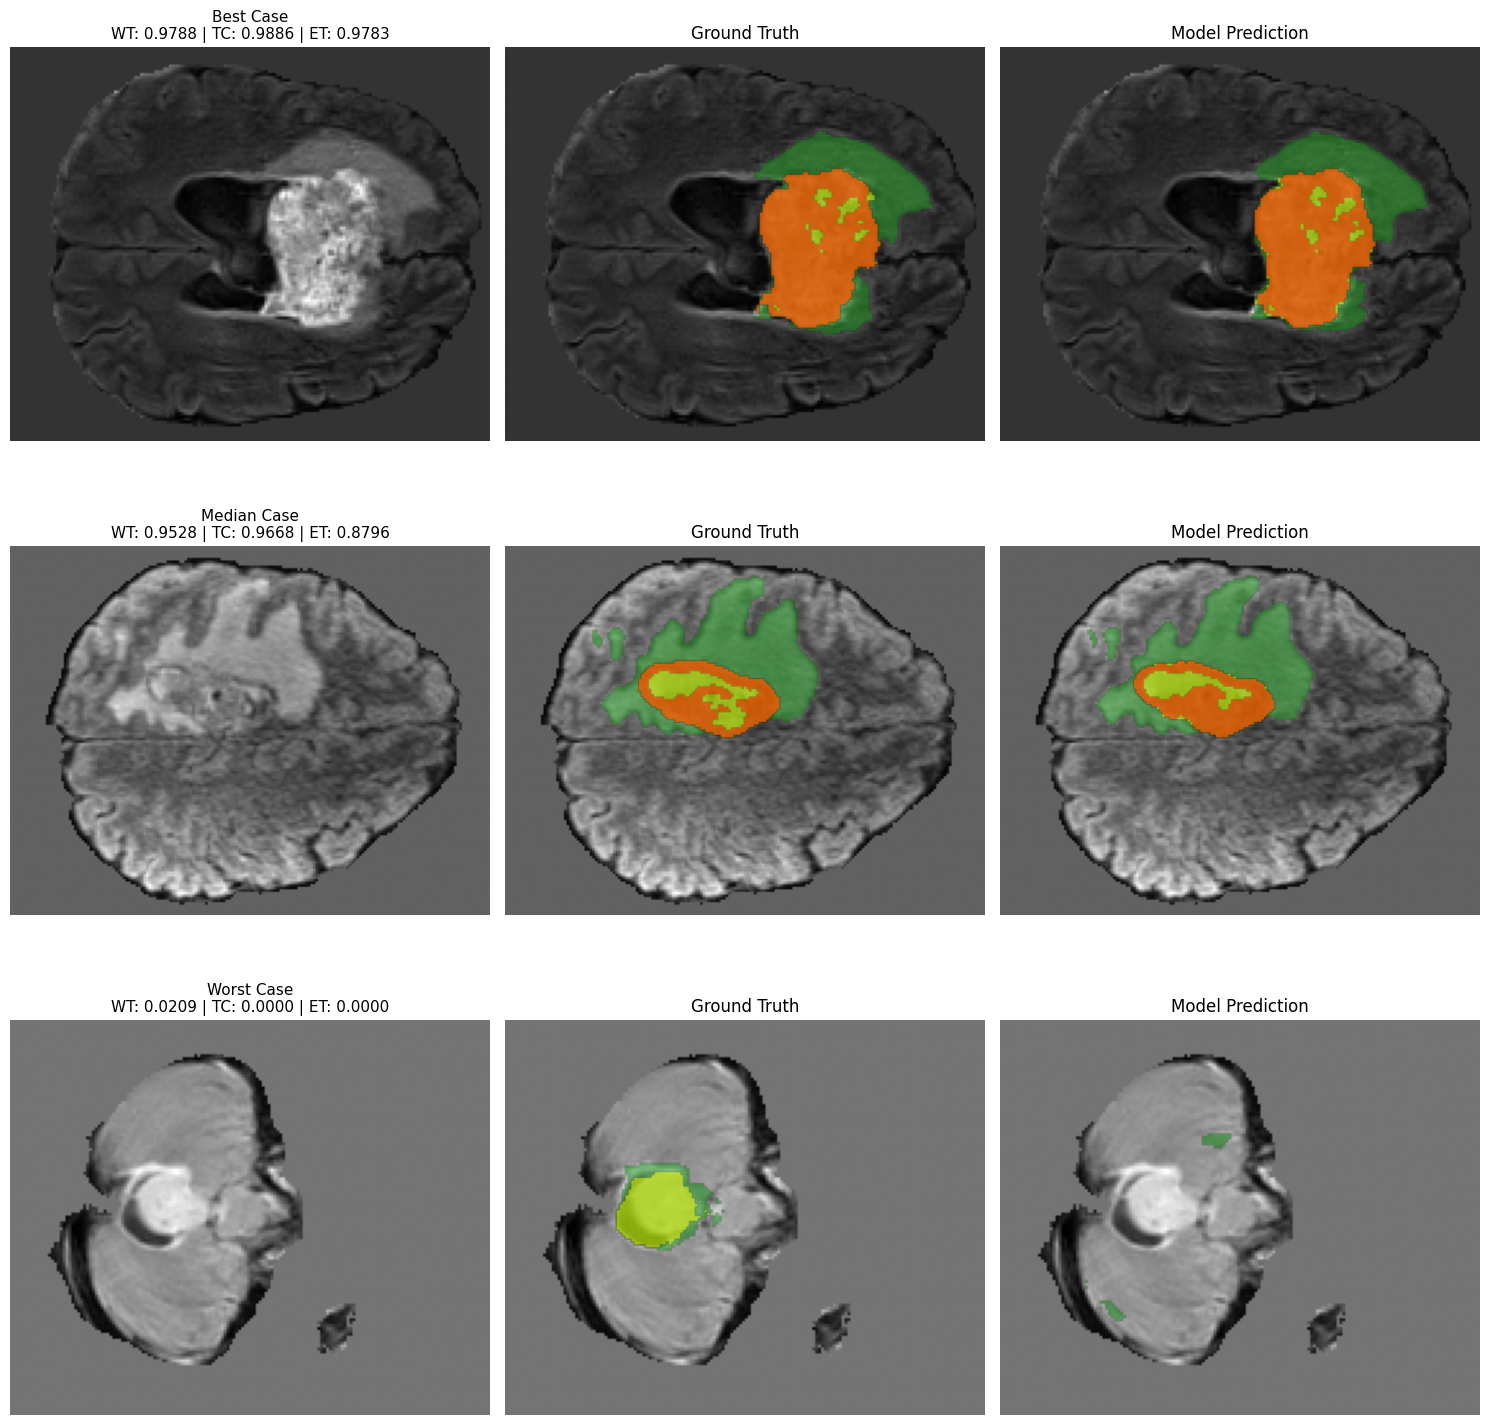

In [28]:

plot_best_median_worst(val_data_list=val_ds, model=model, val_transforms=None, device=device)